In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import pandas as pd

import json
import time

plt.rc('font', size=18)          # controls default text sizes
plt.rc('axes', titlesize=20)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)    # fontsize of the tick labels
plt.rc('ytick', labelsize=15)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "sans-serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

In [2]:
# Hyperparameters
gamma = 0.99
gamma_list = np.cumprod(np.repeat(gamma, 20))

In [3]:
def calc_cost(dir):
    with open(dir, 'r') as f:
        sim = json.load(f)

    cost_list = []
    cost_list_total = []
    sim_rounds = len(sim)
    num_sites = len(sim[0]['hist_cost'])
    
    for i in range(sim_rounds): # Sim
        cost_list_sim = []
        for j in range(num_sites): # Site
            total_cost = 0
            total_time = 0
            for time, cost in sim[i]['hist_cost'][j]:
                # print(cost, cost * (gamma ** total_time), total_time)
                total_cost += cost * (gamma ** total_time)
                total_time += time

            total_cost /= ((1-gamma**(total_time+1))/(1-gamma))
            cost_list.append(-total_cost)
            cost_list_sim.append(-total_cost)
        cost_list_total.append(np.mean(cost_list_sim))
        
    return cost_list, cost_list_total

In [4]:
collab_file_name = "simulation_results/50_5_10_0_collaborative_2024-09-29-09-53-23/result.json"
iso_file_name = "simulation_results/50_5_10_0_isolated_2024-09-29-11-23-45/result.json"
ep_file_name = "simulation_results/50_5_10_0_EP_2024-09-29-16-25-48/result.json"
collab_lap_1_file_name = "simulation_results/50_5_10_1.0_collaborative_2024-10-08-00-17-13/result.json"
collab_lap_2_file_name = "simulation_results/50_5_10_3.0_collaborative_2024-10-07-17-49-10/result.json"

collab_cost, collab_cost_total = calc_cost(collab_file_name)
iso_cost, iso_cost_total = calc_cost(iso_file_name)
ep_cost, ep_cost_total = calc_cost(ep_file_name)
collab_1_cost, collab_1_cost_total = calc_cost(collab_lap_1_file_name)
collab_2_cost, collab_2_cost_total = calc_cost(collab_lap_2_file_name)

In [5]:
sim_accu = [collab_cost, collab_1_cost, collab_2_cost, ep_cost , iso_cost]
sim_accu_total = [collab_cost_total, collab_1_cost_total, collab_2_cost_total, ep_cost_total, iso_cost_total]
df_data = pd.DataFrame(columns=['collab', 'collab_1', 'collab_2', 'EP', 'isolated'])
df_data['collab'] = collab_cost
df_data['collab_1'] = collab_1_cost
df_data['collab_2'] = collab_2_cost
df_data['isolated'] = iso_cost
df_data['EP'] = ep_cost

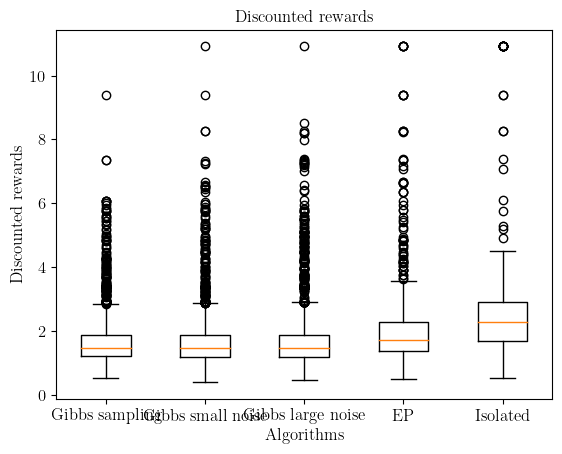

In [6]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Gibbs sampling', 'Gibbs small noise', 'Gibbs large noise', 'EP', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

# plt.savefig("rewards.svg")
plt.title("Discounted rewards")
plt.show()

/tmp/ipykernel_44976/2439195869.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(sim_accu_total, labels=['Collaborative', 'FedSmall', 'FedLarge', 'EP', 'Isolated'])


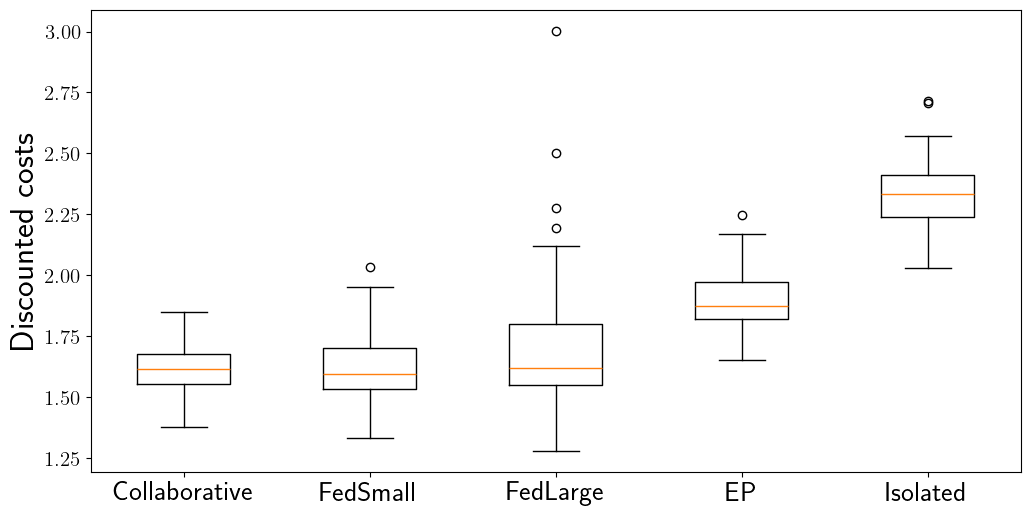

In [11]:
plt.rc('font', size=18)          # controls default text sizes
plt.rc('axes', titlesize=24)     # fontsize of the axes title
plt.rc('axes', labelsize=24)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
plt.rc('ytick', labelsize=15)    # fontsize of the tick labels
plt.rc('legend', fontsize=24)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(sim_accu_total, labels=['Collaborative', 'FedSmall', 'FedLarge', 'EP', 'Isolated'])
# ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted costs")
# ax.set_title("Average discounted costs")

# plt.savefig("rewards.svg")
# plt.title("Discounted rewards")
# plt.savefig("plot/reward.png")
# ax.set_xlabel("1")
fig.savefig('plot/cost_plot.png', bbox_inches='tight')
plt.show()

In [8]:
df_data.describe()

,collab,collab_1,collab_2,EP,isolated
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-1.613465,-1.613615,-1.687456,-1.888401,-2.329740
std,0.659721,0.712526,0.810850,0.828325,0.900990
min,-9.391906,-10.911267,-10.911267,-10.911267,-10.911267
25%,-1.859045,-1.863355,-1.881990,-2.266478,-2.906852
50%,-1.478745,-1.471387,-1.482441,-1.720916,-2.277697
75%,-1.205588,-1.185078,-1.199800,-1.359488,-1.691216
max,-0.540748,-0.389876,-0.472992,-0.501375,-0.533014


In [16]:
np.mean(collab_cost), np.mean(iso_cost)

(-1.6134648609886648, -2.3297398522024917)

In [17]:
np.std(collab_cost), np.std(iso_cost)

(0.6596550131738341, 0.9008996576725792)

In [18]:
N = len(df_data)
std_collab = np.std(collab_cost)
std_iso = np.std(iso_cost)
mu_collab = np.mean(collab_cost)
mu_iso = np.mean(iso_cost)
se = np.sqrt(std_collab**2 / N + std_iso**2 / N)
t_stat = (mu_collab - mu_iso) / se
t_stat

45.35994313584834

In [17]:
t_crit_val = stats.t.ppf(0.975, 2*N-2)
t_crit_val

1.9602012873568364

# Plot values

In [12]:
with open(collab_file_name, 'r') as f:
    sim_collab = json.load(f)
    
with open(ep_file_name, 'r') as f:
    sim_ep = json.load(f)    

with open(iso_file_name, 'r') as f:
    sim_iso = json.load(f)
    
with open(collab_lap_1_file_name, 'r') as f:
    sim_collab_lap_1 = json.load(f)
    
with open(collab_lap_2_file_name, 'r') as f:
    sim_collab_lap_2 = json.load(f)

In [13]:
plot_size = 10
# for i in range(100):
#     size_i_collab = np.stack(sim_collab[i]['values_opt_prob']).shape[-1]
#     size_i_iso = np.stack(sim_iso[i]['values_opt_prob']).shape[-1]
#     size_i_ep = np.stack(sim_ep[i]['values_opt_prob']).shape[-1]
#     size_i_collab_lap_1 = np.stack(sim_collab_lap_1[i]['values_opt_prob']).shape[-1]
#     size_i_collab_lap_2 = np.stack(sim_collab_lap_2[i]['values_opt_prob']).shape[-1]
#     min_size = min(size_i_collab, size_i_iso, size_i_ep, size_i_collab_lap_1, size_i_collab_lap_2)
#     print(min_size)
#     if min_size < plot_size:
#         plot_size = min_size
#     print(plot_size)

value_opt_collab = []
value_opt_ep = []
value_opt_iso = []
value_opt_collab_lap_1 = []
value_opt_collab_lap_2 = []

for i in range(100):
    if np.stack(sim_collab[i]['values_opt_prob']).shape[-1] >= plot_size:
        value_opt_collab.append(np.stack(sim_collab[i]['values_opt_prob'])[:, :plot_size])
    if np.stack(sim_ep[i]['values_opt_prob']).shape[-1] >= plot_size:
        value_opt_ep.append(np.stack(sim_ep[i]['values_opt_prob'])[:, : plot_size])
    if np.stack(sim_iso[i]['values_opt_prob']).shape[-1] >= plot_size:
        value_opt_iso.append(np.stack(sim_iso[i]['values_opt_prob'])[:, : plot_size])
    if np.stack(sim_collab_lap_1[i]['values_opt_prob']).shape[-1] >= plot_size:
        value_opt_collab_lap_1.append(np.stack(sim_collab_lap_1[i]['values_opt_prob'])[:, : plot_size])
    if np.stack(sim_collab_lap_2[i]['values_opt_prob']).shape[-1] >= plot_size:
        value_opt_collab_lap_2.append(np.stack(sim_collab_lap_2[i]['values_opt_prob'])[:, : plot_size])
    
mean_opt_collab = np.mean(np.stack(value_opt_collab), axis=0)
mean_opt_iso = np.mean(np.stack(value_opt_iso), axis=0)
mean_opt_ep = np.mean(np.stack(value_opt_ep), axis=0)
mean_opt_collab_lap_1 = np.mean(np.stack(value_opt_collab_lap_1), axis=0)
mean_opt_collab_lap_2 = np.mean(np.stack(value_opt_collab_lap_2), axis=0)

total_mean_opt_collab = np.mean(np.stack(value_opt_collab).reshape(-1, plot_size), axis=0)
total_mean_opt_iso = np.mean(np.stack(value_opt_iso).reshape(-1, plot_size), axis=0)
total_mean_opt_ep = np.mean(np.stack(value_opt_ep).reshape(-1, plot_size), axis=0)
total_mean_opt_collab_lap_1 = np.mean(np.stack(value_opt_collab_lap_1).reshape(-1, plot_size), axis=0)
total_mean_opt_collab_lap_2 = np.mean(np.stack(value_opt_collab_lap_2).reshape(-1, plot_size), axis=0)

std_opt_collab = np.std(np.stack(value_opt_collab), axis=0)
std_opt_ep = np.std(np.stack(value_opt_ep), axis=0)
std_opt_iso = np.std(np.stack(value_opt_iso), axis=0)
std_opt_collab_lap_1 = np.std(np.stack(value_opt_collab_lap_1), axis=0)
std_opt_collab_lap_2 = np.std(np.stack(value_opt_collab_lap_2), axis=0)

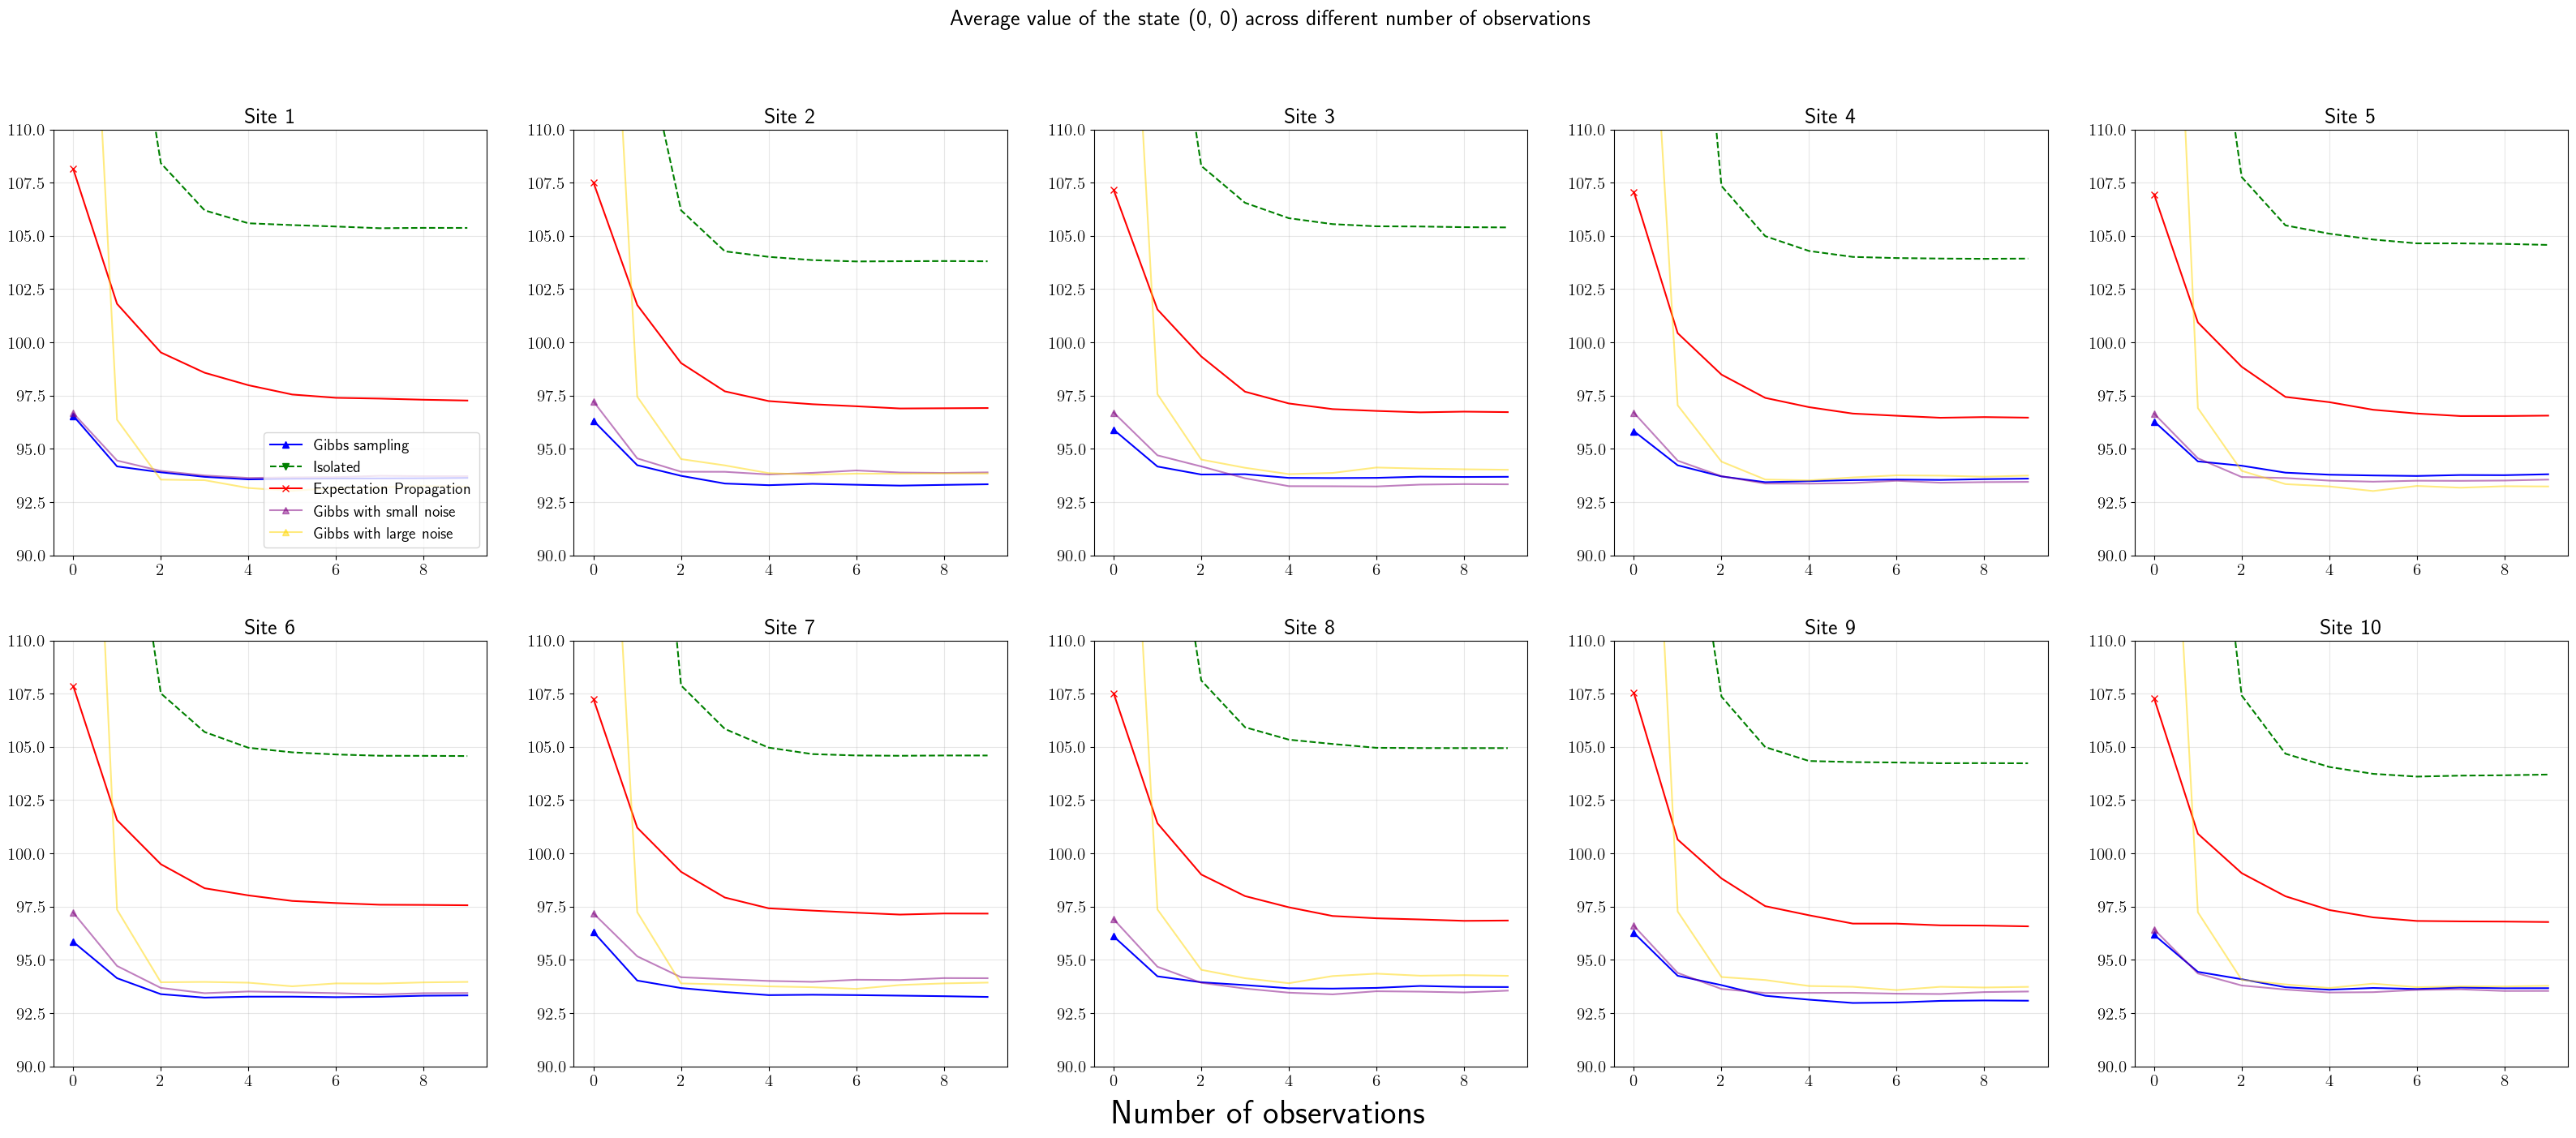

In [15]:
fig, ax = plt.subplots(2, 5, figsize=(40, 15))

start_idx = 0
limit = plot_size
t_list = list(range(start_idx, limit))
# fig.supxlabel("Communication rounds")
# Plotting 10 sites
for i in range(10):        
    value_collab = -mean_opt_collab[i, start_idx:limit]
    std_collab = std_opt_collab[i, start_idx:limit]
    
    value_iso = -mean_opt_iso[i, start_idx:limit]
    std_iso = std_opt_iso[i, start_idx:limit]
    
    value_ep = -mean_opt_ep[i, start_idx:limit]
    std_ep = std_opt_ep[i, start_idx:limit]
    
    value_collab_lap_1 = -mean_opt_collab_lap_1[i, start_idx:limit]
    std_collab_lap_1 = std_opt_collab_lap_1[i, start_idx:limit]
    
    value_collab_lap_2 = -mean_opt_collab_lap_2[i, start_idx:limit]
    std_collab_lap_2 = std_opt_collab_lap_2[i, start_idx:limit]

    ax[i // 5, i % 5].plot(t_list, value_collab, label="Gibbs sampling", color='blue', marker='^', markevery=20)
    ax[i // 5, i % 5].plot(t_list, value_iso, label="Isolated", color='green', marker='v', linestyle='--', markevery=20)
    ax[i // 5, i % 5].plot(t_list, value_ep, label="Expectation Propagation", color='red', marker='x', linestyle='-', markevery=20)
    ax[i // 5, i % 5].plot(t_list, value_collab_lap_1, label="Gibbs with small noise", color='purple', marker='^', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, value_collab_lap_2, label="Gibbs with large noise", color='gold', marker='^', markevery=20, alpha=0.5)
#     ax[i // 5, i % 5].fill_between(t_list, value_collab + std_collab, value_collab - std_collab, color='blue', alpha=0.1)
#     ax[i // 5, i % 5].fill_between(t_list, value_iso + std_iso, value_iso - std_iso, color='green', alpha=0.05)
    ax[i // 5, i % 5].grid(visible=True, alpha=0.3)
    ax[i // 5, i % 5].set_ylim([90, 110])
    ax[i // 5, i % 5].set_title(f'Site {i+1}')
#     ax[i // 5, i % 5].set_yscale('log')
ax[0,0].legend(loc=4)
fig.suptitle("Average value of the state (0, 0) across different number of observations")

# ylabel = r'$\lvert \mu_1^{(i)}-\hat{\mu}_1^{(i)} \rvert$'
fig.text(0.5, 0.07, 'Number of observations', ha='center', va='center', fontsize=30)
# fig.text(0.1, 0.5, ylabel , va='center', rotation='vertical', fontsize=30)

output_dir = f"plot/10site_30_2_"
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
output_dir += jour

result_dir = output_dir + ".png"
fig.savefig(result_dir)

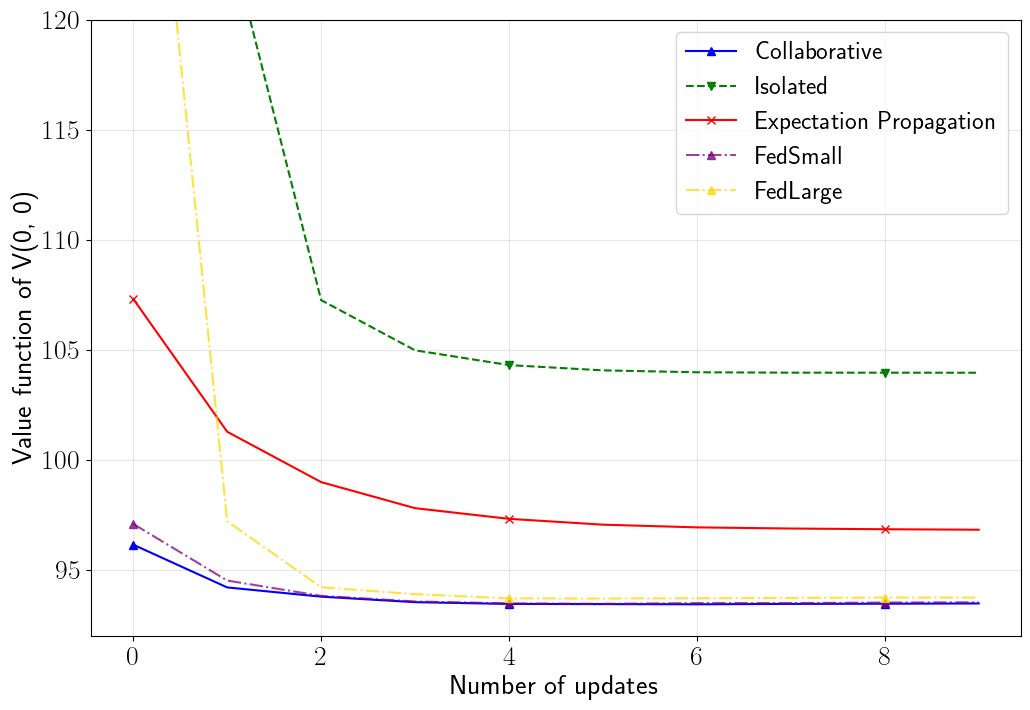

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

plt.rc('font', size=18)          # controls default text sizes
plt.rc('axes', titlesize=24)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
plt.rc('ytick', labelsize=20)    # fontsize of the tick labels
plt.rc('legend', fontsize=18)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

# fig.supxlabel("Communication rounds")
# Plotting 10 sites    
value_collab = -total_mean_opt_collab
value_iso = -total_mean_opt_iso
value_ep = -total_mean_opt_ep
value_collab_lap_1 = -total_mean_opt_collab_lap_1
value_collab_lap_2 = -total_mean_opt_collab_lap_2

ax.plot(t_list, value_collab, label="Collaborative", color='blue', marker='^', markevery=4)
ax.plot(t_list, value_iso, label="Isolated", color='green', marker='v', linestyle='--', markevery=4)
ax.plot(t_list, value_ep, label="Expectation Propagation", color='red', marker='x', linestyle='-', markevery=4)
ax.plot(t_list, value_collab_lap_1, label="FedSmall", color='purple', marker='^', linestyle='dashdot', markevery=4, alpha=0.75)
ax.plot(t_list, value_collab_lap_2, label="FedLarge", color='gold', marker='^', linestyle='dashdot', markevery=4, alpha=0.75)
#     ax[i // 5, i % 5].fill_between(t_list, value_collab + std_collab, value_collab - std_collab, color='blue', alpha=0.1)
#     ax[i // 5, i % 5].fill_between(t_list, value_iso + std_iso, value_iso - std_iso, color='green', alpha=0.05)
ax.grid(visible=True, alpha=0.3)
ax.set_ylim([92, 120])
ax.set_xlabel('Number of updates')
ax.set_ylabel('Value function of V(0, 0)')
# ax.set_title(f'The value of the initial state')
ax.legend(loc=1)
# fig.suptitle("Average value of the state (0, 0) across different number of observations")
# ax.set_title("Average value of the state (0, 0) across different number of observations")
# ylabel = r'$\lvert \mu_1^{(i)}-\hat{\mu}_1^{(i)} \rvert$'
# fig.text(0.5, 0.07, 'Number of observations', ha='center', va='center', fontsize=30)
# fig.text(0.1, 0.5, ylabel , va='center', rotation='vertical', fontsize=30)

output_dir = f"plot/val_fn_avg_"
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
output_dir += jour

result_dir = output_dir + ".png"
fig.savefig(result_dir, bbox_inches='tight')

# Policy

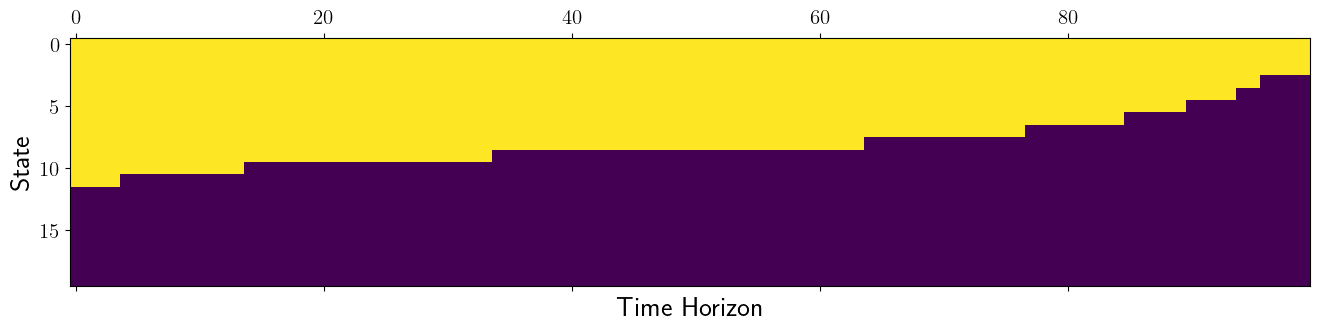

In [12]:
plt.matshow(np.flip(np.transpose(np.stack(sim_collab[0]['policy'][24])), axis=0))
plt.xlabel("Time Horizon")
plt.ylabel("State")
# plt.title("Optimal policy from site 1")
plt.savefig("plot/opt_policy.png", bbox_inches='tight')
plt.show()

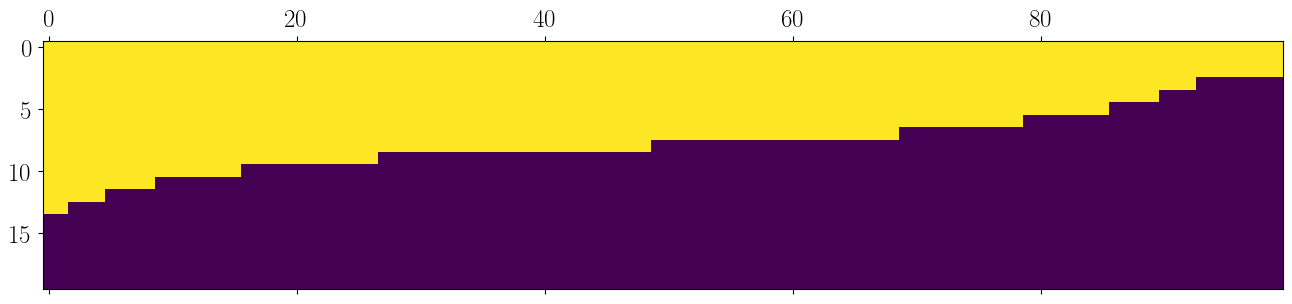

In [27]:
plt.matshow(np.flip(np.transpose(np.stack(sim_iso[0]['policy'][24])), axis=0))
plt.show()

In [5]:
with open("simulation_results/2024-09-17-02-01-35_result_collaborative.json", 'r') as f:
    sim = json.load(f)

In [8]:
sim[0]['hist_value_gap']

[[512.1220723621494,
  412.2214459677709,
  455.5889703240961,
  389.8044057711538,
  732.0891989561767,
  728.9127942686313,
  787.0009003859662,
  496.6929791327544,
  500.95253405322904,
  464.0035498363004,
  524.9926160983092,
  426.0424069589799,
  362.2990667767459,
  281.70661533242526,
  311.8355170421673,
  262.53990321063947,
  279.94885377357514,
  271.7887468229691,
  273.66111596912737,
  280.27836358153104,
  276.4005346785893,
  277.2562170547246,
  280.86325951786483,
  285.253239517542,
  278.5694888851064,
  287.62342425193225,
  277.05348463473405,
  285.9464365411267,
  276.23897444173,
  281.50831456235625,
  284.0882936176661,
  281.2765852652167,
  287.80847410568646,
  283.01871421286654,
  272.1685527557239,
  285.15320722871564,
  284.6108532354235,
  282.6105145106731,
  284.2470852551062,
  277.39838992821507,
  290.5678156820924,
  283.38667051883573,
  287.1772699939985,
  286.8832358984664,
  285.2965350287257,
  287.15994474456727],
 [728.4583954847267,

In [ ]:
with open("simulation_results/2024-09-15-20-37-17_result_isolated.json", 'r') as f:
    sim_iso = json.load(f)